<a href="https://colab.research.google.com/github/knc6/aqc/blob/main/notebooks/module1/Module1_Quantum_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1 — Quantum Foundations
### Applied Quantum Computing · Johns Hopkins University · Prof. Kamal Choudhary (kchoudh2@jhu.edu)

This is the **hands-on studio notebook** for the that accompanies the Module 1 lecture.

You will build single- and multi-qubit states, apply gates, inspect amplitudes with `Statevector`, and create Bell/GHZ states on a simulator and on real hardware.

**Companion IBM Quantum Learning course:** *Use a quantum computer today / Basics of Quantum Information* — see [https://quantum.cloud.ibm.com/learning/en/courses](https://quantum.cloud.ibm.com/learning/en/courses)

Useful links: [Qiskit](https://www.ibm.com/quantum/qiskit) · [Qiskit docs](https://docs.quantum.ibm.com/) · [IBM Quantum](https://quantum.ibm.com/)

> These examples are intentionally small and **crude, for learning purposes** — the goal is to build intuition and a working pipeline, not production results. Submit your completed notebook to the course GitHub repo.

**Note:** we pin package versions because Qiskit occasionally renames/moves APIs between releases. If a later Qiskit version breaks a cell, check the [migration guides](https://docs.quantum.ibm.com/migration-guides). Run the install cell once, then **restart the kernel**.

## Note: If you are not familiar with Python/Linux, please go through notebooks here: https://github.com/atomgptlab/jarvis-tools-notebooks#basics

In [1]:
%%time
!pip install -q "qiskit>=2.0" qiskit-aer qiskit-ibm-runtime matplotlib numpy scipy pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.

## 1. Setup & imports

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# See also this docs: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit

# Important `QuantumCircuit` Parameters in Qiskit

The `QuantumCircuit` class can be created in several ways. The most common parameters specify the number of qubits and classical bits.

## 1. Basic Form

```python
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 3)
```

This creates:

* **3 qubits**
* **3 classical bits**

---

## 2. Qubits Only

```python
qc = QuantumCircuit(3)
```

This creates:

* **3 qubits**
* **0 classical bits**

---

## 3. Add a Circuit Name

You can give your quantum circuit a name:

```python
qc = QuantumCircuit(3, 3, name="my_circuit")
```

The `name` parameter helps identify your circuit, especially when working with multiple circuits.

---

## 4. Using Quantum and Classical Registers

For more control, you can explicitly create registers:

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qr = QuantumRegister(3, "q")
cr = ClassicalRegister(3, "c")

qc = QuantumCircuit(qr, cr)
```

This creates:

**Quantum Register:**

* `q` → 3 qubits

**Classical Register:**

* `c` → 3 classical bits

### Multiple Registers

You can also create multiple groups of qubits:

```python
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

input_reg = QuantumRegister(2, "input")
ancilla_reg = QuantumRegister(1, "ancilla")
output_reg = ClassicalRegister(2, "output")

qc = QuantumCircuit(input_reg, ancilla_reg, output_reg)
```

This creates:

* `input` → 2 qubits
* `ancilla` → 1 qubit
* `output` → 2 classical bits

---

## 5. Global Phase

Another quantum-specific parameter is `global_phase`.

```python
qc = QuantumCircuit(3, global_phase=0.5)
```

A global phase multiplies the entire quantum state by:

$$
e^{i\phi}
$$

For example:

$$
|\psi\rangle \rightarrow e^{i\phi}|\psi\rangle
$$

A global phase generally cannot be directly measured, but it can be important during circuit transformations and decompositions.

---

# Summary of Important Parameters

| Parameter           | Example                | Meaning                                 |
| ------------------- | ---------------------- | --------------------------------------- |
| Number of qubits    | `QuantumCircuit(3)`    | Creates 3 qubits                        |
| Classical bits      | `QuantumCircuit(3, 3)` | Creates 3 qubits and 3 classical bits   |
| `name`              | `name="test"`          | Gives the circuit a name                |
| `QuantumRegister`   | `QuantumRegister(3)`   | Creates a named group of qubits         |
| `ClassicalRegister` | `ClassicalRegister(3)` | Creates a named group of classical bits |
| `global_phase`      | `global_phase=0.5`     | Sets an overall quantum phase           |

---

# Recommended Forms for Beginners

Start primarily with these three forms:

```python
# Only qubits
qc = QuantumCircuit(3)

# Qubits + classical measurement bits
qc = QuantumCircuit(3, 3)

# Named circuit
qc = QuantumCircuit(3, 3, name="bell_circuit")
```

## Key Takeaway

> `QuantumCircuit(n)` creates **n qubits only**.

> `QuantumCircuit(n, m)` creates **n qubits and m classical bits**.

---

## Next Step

The next step is learning how to add operations and gates to a quantum circuit:

* `qc.h()` — Hadamard gate
* `qc.x()` — Pauli-X gate
* `qc.cx()` — Controlled-NOT gate
* `qc.measure()` — Measurement
* `qc.reset()` — Reset a qubit






## 2. Running on simulators

### 2.1 A qubit and single-qubit gates
Prepare $H|0\rangle=|+\rangle$, add a relative phase, inspect the exact amplitudes.

amplitudes: [0.653-0.271j 0.653+0.271j]
probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


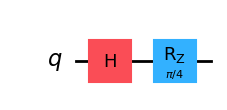

In [3]:
qc = QuantumCircuit(1)
qc.h(0)
qc.rz(np.pi/4, 0)          # relative phase (invisible to Z-basis probs)
sv = Statevector(qc)
print('amplitudes:', np.round(sv.data, 3))
print('probabilities:', sv.probabilities_dict())
qc.draw('mpl')

## See also: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector

### 2.2 Verify a gate identity
`H Z H = X` — check it numerically (good debugging habit).

In [4]:
qc = QuantumCircuit(1)
qc.h(0); qc.z(0); qc.h(0)
X = np.array([[0, 1], [1, 0]])
print('HZH == X ?', np.allclose(Operator(qc).data, X))

HZH == X ? True


### 2.3 Bell and GHZ states
Entanglement: correlated outcomes, never `01`/`10` for a Bell pair.

In [5]:
bell = QuantumCircuit(2)
bell.h(0); bell.cx(0, 1)
print('Bell:', Statevector(bell).probabilities_dict())

ghz = QuantumCircuit(3)
ghz.h(0); ghz.cx(0, 1); ghz.cx(1, 2)
print('GHZ :', Statevector(ghz).probabilities_dict())

Bell: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}
GHZ : {np.str_('000'): np.float64(0.4999999999999999), np.str_('111'): np.float64(0.4999999999999999)}


### 2.4 Measurement and shot statistics
Increase `shots` and watch the sampling error shrink.

In [ ]:
qc = QuantumCircuit(2, 2)
qc.h(0); qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
sim = AerSimulator()
for s in (20, 200, 4000):
    counts = sim.run(qc, shots=s).result().get_counts()
    print(f'shots={s:5d} -> {counts}')

shots=   20 -> {'11': 8, '00': 12}
shots=  200 -> {'11': 116, '00': 84}
shots= 4000 -> {'11': 2017, '00': 1983}


## See also: https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator

## 3. Running on real hardware (IBM Quantum)



Go to **quantum.ibm.com**, sign in, copy your API token, and save it **once**:

### https://quantum.cloud.ibm.com/signin?redirectTo=%2F >> API Key >> Create

```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="PASTE_TOKEN")
```

Then run the cell below. Open-plan queues can be long,  develop on simulators first and submit hardware jobs deliberately.

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")

In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit import transpile

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print('using', backend.name)

qc = QuantumCircuit(2, 2); qc.h(0); qc.cx(0, 1); qc.measure([0,1],[0,1])
tqc = transpile(qc, backend)
job = SamplerV2(backend).run([tqc], shots=4096)
print('job id:', job.job_id())
# later: res = job.result(); print(res[0].data.c.get_counts())

qiskit_runtime_service.__init__:WARNING:2026-09-01 07:40:44,338: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: CHM232. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-01 07:40:44,708: Loading instance: CHM232, plan: premium
qiskit_runtime_service.backends:WARNING:2026-09-01 07:40:48,534: Using instance: CHM232, plan: premium


using ibm_miami
job id: dab830errl7c7386h370


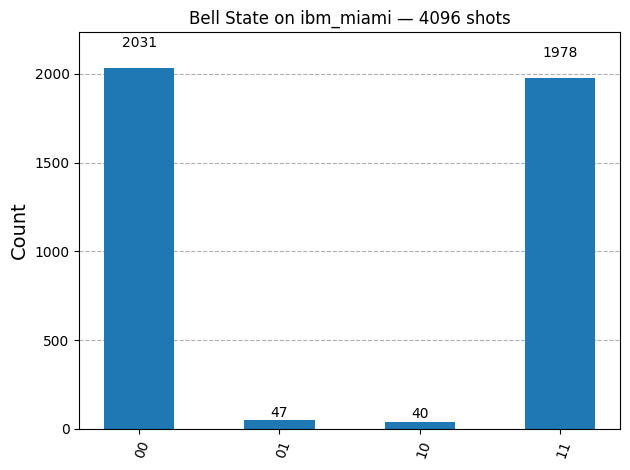

In [10]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

counts = res[0].data.c.get_counts()

fig = plot_histogram(
    counts,
    title=f"Bell State on {backend.name} — 4096 shots"
)

display(fig)

Ideal Bell state behavior: 00 → 50%
11 → 50%
01 →  0%
10 →  0%

So the histogram is essentially a visual measurement of how closely the real quantum computer produced the ideal Bell state. Even a perfect device wouldn't necessarily give exactly 2048/2048.